# Analyse sur les truites de notre échantillon dans le but de généraliser à la population

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

from utils.calcul_volume_fct import calculate_volumes, calculate_eggs_volumes
from utils.stats_fct import distribution, nuage_points, linear_regression, plot_evolution_curves

In [3]:
# ---- Importation du fichier avec les metadatas ----
file_path = '../utils/correspondance_echo_final.xlsx'
df = pd.read_excel(file_path, dtype={"image_id": str})

unique_id = np.unique(df.cap_id)

## Masques réels

### Récupère le vrai volume des gonades et des oeufs de l'échantillon

In [4]:
all_resultats_cavite = []
all_resultats_oeufs = []

# --- Calcul des volumes par poisson ----
for id in unique_id:
    # On récupère les échographies associées au poisson
    echos_poisson = df[df.cap_id == id]
    
    # Calcul des volumes
    res_poisson_cavite = calculate_volumes(echos_poisson, id, "data/labels/YOLO/cavite/") # "data/labels/YOLO/cavite/" ou "U-NET/masks/3_classes/true_"
    res_poisson_oeufs = calculate_eggs_volumes(echos_poisson, id, "data/labels/YOLO/oeufs/") # "data/labels/YOLO/oeufs/" ou "U-NET/masks/3_classes/true_"
    
    # On convertit le dict du poisson en DataFrame et on l'ajoute à la liste globale
    all_resultats_cavite.append(pd.DataFrame(res_poisson_cavite))
    all_resultats_oeufs.append(pd.DataFrame(res_poisson_oeufs))

# On fusionne tous les résultats en un seul DataFrame final
df_res_true = pd.concat(all_resultats_cavite + all_resultats_oeufs, ignore_index=True)
df_res_true = df_res_true.sort_values(by=['id poisson', 'position echo'])
df_res_true.to_csv("true_volumes_ech.csv", index=False) # Sauvegarde du DataFrame en CSV

Position de l'écho : 1.0, surface gonades : 0.41 cm2, rayon : 0.36 cm, surface cavité : 1.34 cm2
Position de l'écho : 3.0, surface gonades : 0.43 cm2, rayon : 0.37 cm, surface cavité : 1.09 cm2
Position de l'écho : 4.0, surface gonades : 0.26 cm2, rayon : 0.29 cm, surface cavité : 0.56 cm2
Poisson n°: 356302, Nombre d'échos : 3/3, Volume total gonades: 1.45 cm3, volume total cavité: 3.82 cm3
-----------------------
Echo n° : 1, surface oeufs : 0.029 cm2, rayon : 0.096 cm, volume : 0.0037 cm3
Poisson n°: 356302, Nombre d'échos : 1/1, Volume total oeufs: 0.0037 cm3
-----------------------
Position de l'écho : 0.0, surface gonades : 0.74 cm2, rayon : 0.48 cm, surface cavité : 1.68 cm2
Position de l'écho : 2.0, surface gonades : 1.17 cm2, rayon : 0.61 cm, surface cavité : 1.89 cm2
Position de l'écho : 4.0, surface gonades : 0.99 cm2, rayon : 0.56 cm, surface cavité : 1.13 cm2
Position de l'écho : 6.0, surface gonades : 0.41 cm2, rayon : 0.36 cm, surface cavité : 0.60 cm2
Poisson n°: 356418

In [23]:
# ----- 1. Fusionne les données des échographies avec celles des poissons ----
df_res_true["id poisson"] = df_res_true["id poisson"].astype(str)
df_res_true = pd.merge(df_res_true, df[[ "image_id", "poids_poisson", "long_poisson", "age_poisson" ]], on="image_id", how="left")

# ----- 2. Divise les données entre les poissons et les œufs ----
df_true_fish = df_res_true[df_res_true["position echo"] != "œufs"]
df_true_eggs = df_res_true[df_res_true["position echo"] == "œufs"]

# ----- 3. Divise les données selon la position de l'écho ----
df_debut = df_true_fish[df_true_fish['position echo'] < 2]
df_fin = df_true_fish[df_true_fish['position echo'] >= 2]

# ----- 4. Jeu de données final avec uniquement les volumes  -----
df_final_true = df_res_true[["id poisson", "image_id" , "volume_cavite", "volume_gonade", "echelle", "volume_moyen_oeufs_mm3", 
                        "poids_poisson", "long_poisson", "age_poisson"]].groupby('id poisson', as_index=False).last()
df_final_true = df_final_true.dropna()

#------ 5. Calcul et ajout de la fécondité -------
df_final_true["fecondite"] = (df_final_true["volume_gonade"] * 1000) / df_final_true["volume_moyen_oeufs_mm3"]

### Graphiques pour visualiser l'évolution de la surface des gonades pour un meme poisson

In [7]:
#Compter le nombre de lignes par poisson
poisson_counts = df_true_fish['id poisson'].value_counts()

# Filtrer les poissons avec exactement 2 lignes
poissons_2_lines = poisson_counts[poisson_counts == 2].index
df_2_lines = df_true_fish[df_true_fish['id poisson'].isin(poissons_2_lines)]

# Filtrer les poissons avec plus de 2 lignes
poissons_other = poisson_counts[poisson_counts > 2].index
df_other = df_true_fish[df_true_fish['id poisson'].isin(poissons_other)]

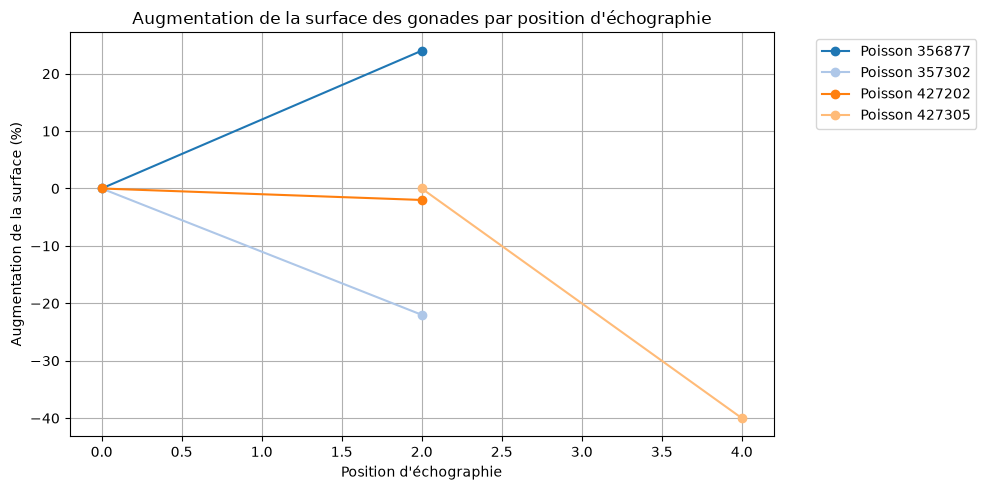

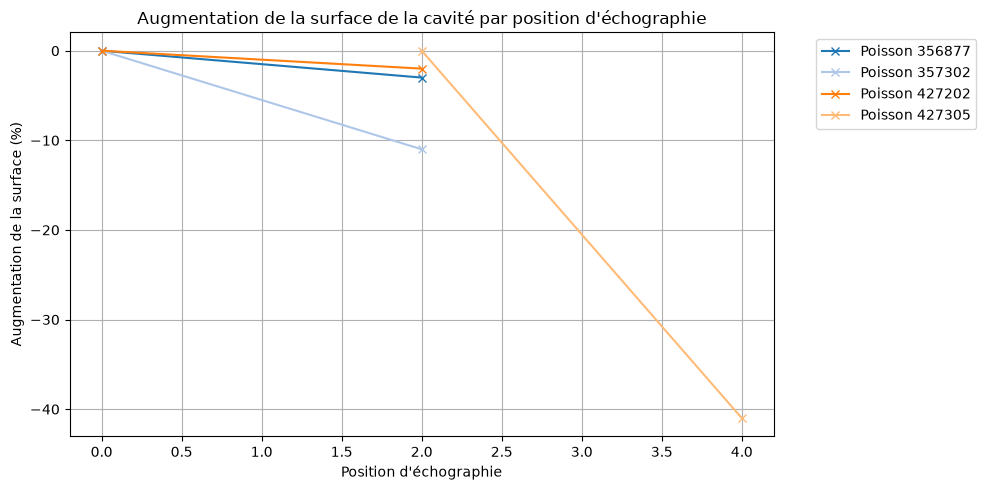

In [9]:
plot_evolution_curves(df_2_lines)

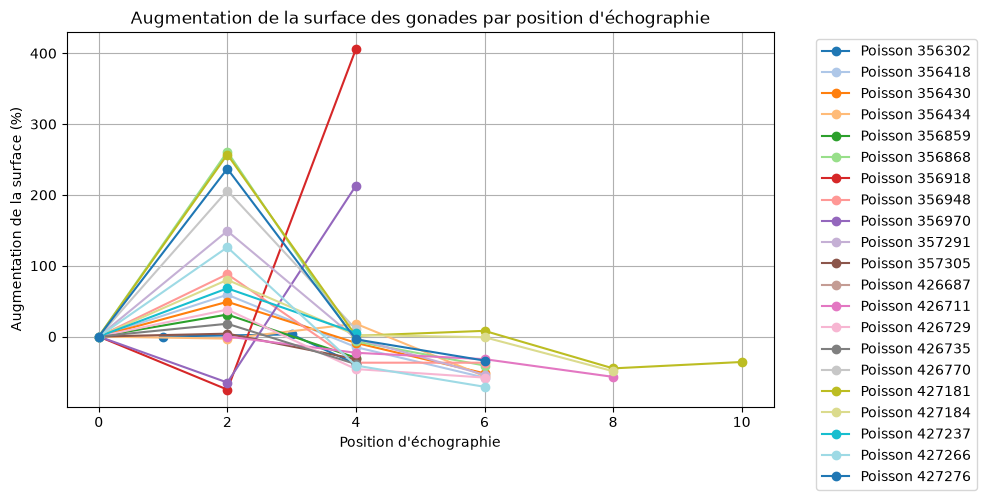

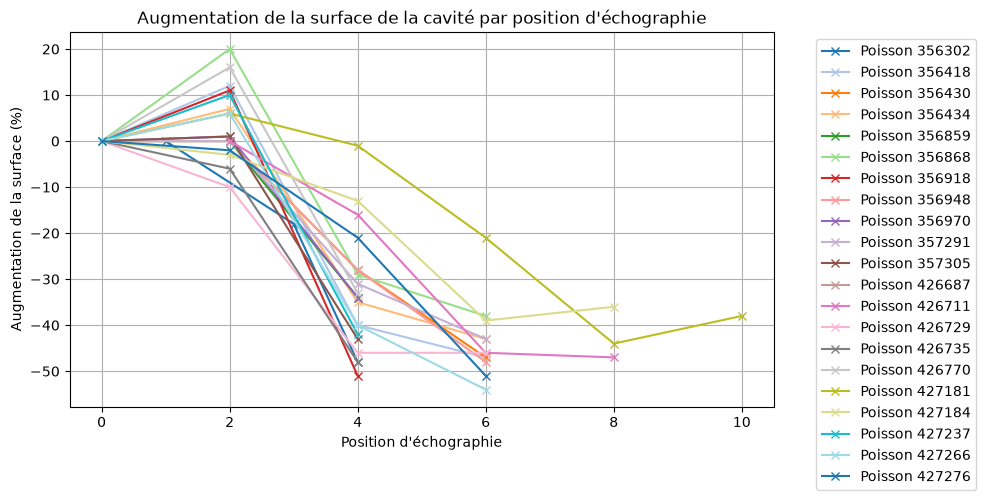

In [10]:
plot_evolution_curves(df_other)

### Graphique pour voir le lien entre la cavité et la gonade

Corrélation : 0.6318795889308401


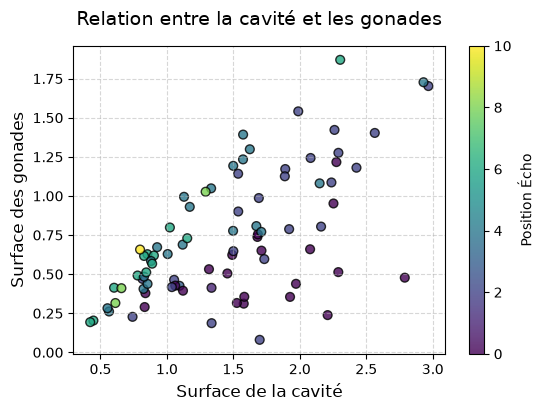

MissingDataError: exog contains inf or nans

In [8]:
print(f"Corrélation : {df_true_fish.surface_cavite.corr(df_true_fish.surface_gonade)}") # Corrélation

nuage_points(
    x=df_true_fish.surface_cavite, 
    y=df_true_fish.surface_gonade,
    color_var=df_true_fish['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

# Tranformations logarithmiques car non linéaire
linear_regression(df_true_fish.surface_cavite, df_true_fish.surface_gonade)

Corrélation : 0.3950918948666595


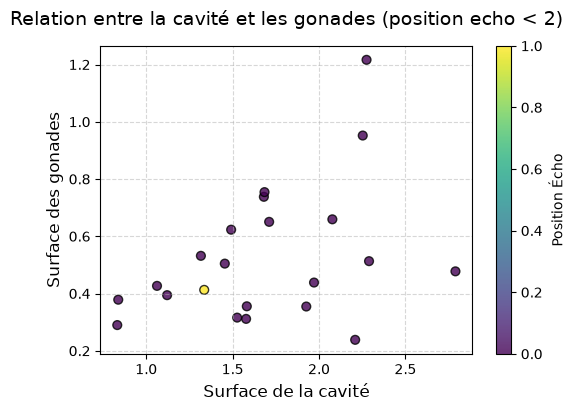

MissingDataError: exog contains inf or nans

In [12]:
print(f"Corrélation : {df_debut.surface_cavite.corr(df_debut.surface_gonade)}") # Corrélation

nuage_points(
    x=df_debut.surface_cavite, 
    y=df_debut.surface_gonade,
    color_var=df_debut['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades (position echo < 2)", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

# Tranformations logarithmiques car non linéaire
linear_regression(df_debut.surface_cavite, df_debut.surface_gonade)

In [29]:
df_debut.loc[118]

KeyError: 118

Corrélation : 0.8154546949745247


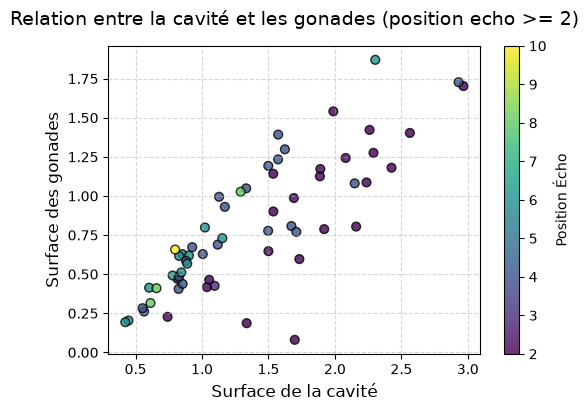

In [13]:
print(f"Corrélation : {df_fin.surface_cavite.corr(df_fin.surface_gonade)}") # Corrélation

nuage_points(
    x=df_fin.surface_cavite, 
    y=df_fin.surface_gonade,
    color_var=df_fin['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades (position echo >= 2)", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

### Détection des anomalies

In [9]:
for id in df_true_fish['id poisson'].unique():
    rows = df_true_fish[df_true_fish['id poisson'] == id]
    nb_rows = len(rows)
    pb_list = []

    # Détection des potentiels problèmes de surfaces pour des poissons avec plus de 2 échos
    if nb_rows > 2:
        for i in range(nb_rows):
            # Si l'écho est à Op+2, alors elle ne doit pas avoir une augmentation négative de la surface des gonades
            if rows.iloc[i]["position echo"]==2.0:
                value = rows.iloc[i].augmentation_surface_gonade
                if value < -10 : # Tolerance de 10% pour les diminutions de surface des gonades
                    pb_list.append(1)
                else:
                    pb_list.append(0)

            # Si l'écho est à Op+3 ou plus, alors elle ne doit pas avoir une augmentation de la surface des gonades supérieure à 10%
            elif rows.iloc[i]["position echo"]>2.0:
                value = rows.iloc[i].augmentation_surface_gonade
                if value > 10 : # Tolerance de 10% pour les augmentations de surface des gonades
                    pb_list.append(1)
                else:
                    pb_list.append(0)
            else:
                pb_list.append(0)


        for i in range(len(pb_list)-1):
            # Si il y a deux "1" à la suite, alors l'erreur est sur la première échographie où il y a un "1"
            if pb_list[i] == 1 and pb_list[i+1] == 1:
                print(f"Poisson : {id} - Problèmes : {pb_list}")
                print(f"Poisson : {id} - Problème sur l'écho à la position {rows.iloc[i]['position echo']} (diminution surface gonade : {rows.iloc[i]['augmentation_surface_gonade']})")
                break
        # Si il y a un "1" seul à la deuxième position, alors l'erreur est sur la première échographie
        if pb_list[1] == 1 and pb_list[0] == 0 and pb_list[2] == 0:
            print(f"Poisson : {id} - Problèmes : {pb_list}")
            print(f"Poisson : {id} - Problème sur l'écho à la position {rows.iloc[0]['position echo']} (diminution surface gonade : {rows.iloc[0]['augmentation_surface_gonade']})")

Poisson : 356918 - Problèmes : [0, 1, 1]
Poisson : 356918 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -75.0)
Poisson : 356970 - Problèmes : [0, 1, 1]
Poisson : 356970 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -65.0)


## Graphique pour voir le lien entre la cavité/gonade.oeufs et le poisson taille/poids

### Rapport gonado-somatique : poids gonade / poids poisson * 100

Quantiles GSI: [nan nan nan nan nan nan nan]


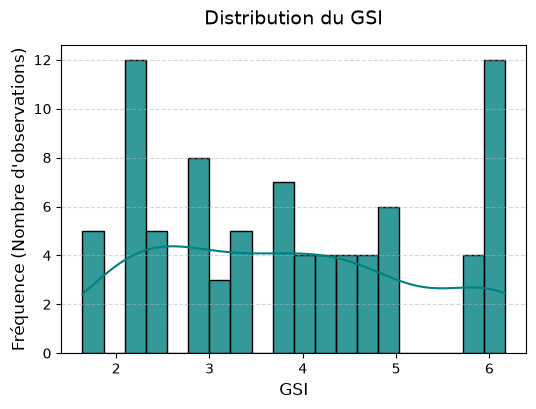

In [10]:
GSI = df_true_fish.volume_gonade / df_true_fish.poids_poisson * 100
print(f"Quantiles GSI: {np.quantile(GSI, q = (0, 0.05, 0.25, 0.5, 0.75, 0.95, 1))}") # Affiche les quantiles du GSI
distribution(GSI, "Distribution du GSI", "GSI", couleur='teal', bins=20)

Est-ce que le rapport gonado somatique correspond à celui que l'on ait sensé avoir en octobre ?

### Relation poids/longueur poisson et volume gonade

In [1]:
print(f"Corrélation : {df_true_fish.volume_gonade.corr(df_true_fish.poids_poisson)}") # Corrélation

nuage_points(
    x=df_true_fish.poids_poisson, # long_poisson ou poids_poisson
    y=df_true_fish.volume_gonade,
    titre="Relation entre volumes gonades et poids du poisson", 
    xlabel="Poids du poisson", 
    ylabel="Volume des gonades",
    couleur='teal'
    )

NameError: name 'df_true_fish' is not defined

### Relation poids/longueur poisson et volume cavité

Corrélation : 0.9018621996122892


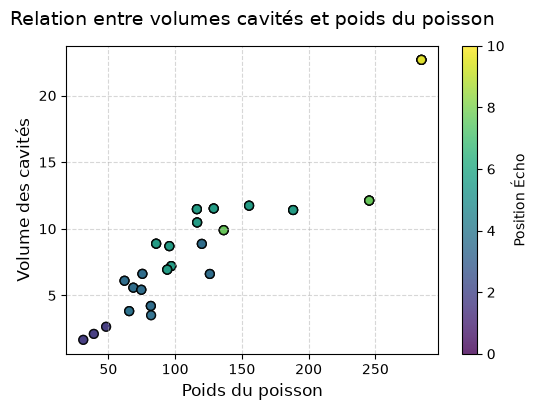

In [12]:
print(f"Corrélation : {df_true_fish.volume_cavite.corr(df_true_fish.poids_poisson)}") # Corrélation

nuage_points(
    x=df_true_fish.poids_poisson, # long_poisson ou poids_poisson
    y=df_true_fish.volume_cavite,
    color_var=df_true_fish['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre volumes cavités et poids du poisson", 
    xlabel="Poids du poisson", 
    ylabel="Volume des cavités",
    couleur='teal'
    )

## Analyse des résultats des oeufs distribution

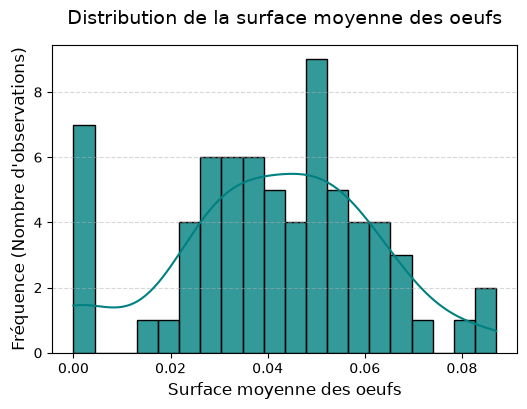

[0.         0.         0.02922601 0.04227601 0.05411849 0.07026808
 0.08704302]


In [13]:
distribution(df_true_eggs.surface_moyenne_oeufs_mm2, "Distribution de la surface moyenne des oeufs", "Surface moyenne des oeufs (mm²)", couleur='teal', bins=20)
print(np.quantile(df_true_eggs.surface_moyenne_oeufs_mm2, q = (0, 0.05, 0.25, 0.5, 0.75, 0.95, 1))) # Affiche les quantiles de la surface moyenne des oeufs en mm²

### Relation volume des oeufs et poids/longueur poisson

In [14]:
df_true_eggs[df_true_eggs.poids_poisson > 350]

,id poisson,image_id,position echo,surface_cavite,surface_gonade,volume_cavite,volume_gonade,echelle,augmentation_surface_gonade,augmentation_surface_cavite,surface_moyenne_oeufs,volume_moyen_oeufs,poids_poisson,long_poisson,age_poisson
70,363346,0004986,œufs,NaN,NaN,NaN,NaN,3.1,NaN,NaN,0.029226,0.003759,401.9,325,4+34
71,363346,0004987,œufs,NaN,NaN,NaN,NaN,3.1,NaN,NaN,0.022974,0.002619,401.9,325,4+34


Corrélation : 0.19605613409138467


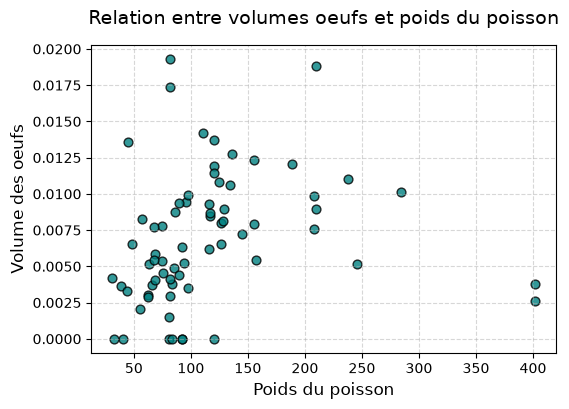

In [15]:
print(f"Corrélation : {df_true_eggs.volume_moyen_oeufs_mm3.corr(df_true_eggs.poids_poisson)}") # Corrélation

nuage_points(
    x=df_true_eggs.poids_poisson, # long_poisson ou poids_poisson
    y=df_true_eggs.volume_moyen_oeufs_mm3,
    titre="Relation entre volumes oeufs et poids du poisson", 
    xlabel="Poids du poisson", 
    ylabel="Volume des oeufs (mm³)",
    couleur='teal'
    )

### Relation volume des oeufs et volume/longueur gonade/poisson

Corrélation : 0.3839717598617084


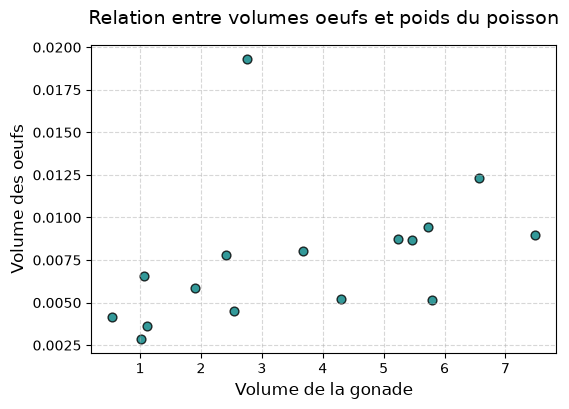

In [18]:
print(f"Corrélation : {df_final_true.volume_moyen_oeufs_mm3.corr(df_final_true.volume_gonade)}") # Corrélation

nuage_points(
    x=df_final_true.volume_gonade, # long_poisson ou poids_poisson
    y=df_final_true.volume_moyen_oeufs_mm3,
    titre="Relation entre volumes oeufs et poids du poisson", 
    xlabel="Volume de la gonade", 
    ylabel="Volume des oeufs (mm³)",
    couleur='teal'
    )

### Distribution de la fécondité

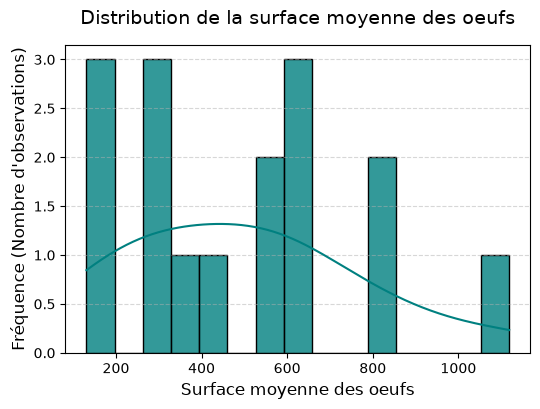

[ 130.93949978  139.72111193  309.03768621  495.40058831  610.2116017
  905.83117826 1118.62591012]


In [20]:
distribution(df_final_true.fecondite, "Distribution de la surface moyenne des oeufs", "Surface moyenne des oeufs", couleur='teal', bins=15)
print(np.quantile(df_final_true.fecondite, q = (0, 0.05, 0.25, 0.5, 0.75, 0.95, 1))) # Affiche les quantiles de la surface moyenne des oeufs

### Relation fécondite / poisson

Corrélation : 0.7560523404473339


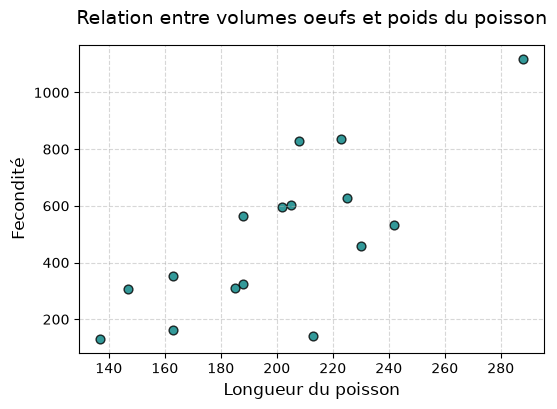

In [ ]:
print(f"Corrélation : {df_final_true.fecondite.corr(df_final_true.long_poisson)}") # Corrélation

nuage_points(
    x=df_final_true.long_poisson, # long_poisson ou poids_poisson
    y=df_final_true.fecondite,
    titre="Relation entre fécondité et longueur du poisson", 
    xlabel="Longueur du poisson", 
    ylabel="Fecondité",
    couleur='teal'
    )

## Masques prédits

### Récupère le volume prédits des gonades de l'échantillon

In [24]:
all_resultats_cavite = []
all_resultats_oeufs = []

# --- Calcul des volumes par poisson ----
for id in unique_id:
    # On récupère les échographies associées au poisson
    echos_poisson = df[df.cap_id == id]
    
    # Appel de la fonction autonome
    res_poisson_fish = calculate_volumes(echos_poisson, id, "UNet/masks/test/UNet/pred_") # "data/labels/YOLO/cavite/" ou "U-NET/masks/3_classes/true_"
    res_poisson_oeufs = calculate_eggs_volumes(echos_poisson, id, "data/labels/YOLO/oeufs/") # "data/labels/YOLO/oeufs/" ou "U-NET/masks/3_classes/true_"

    
    # On convertit le dict du poisson en DataFrame et on l'ajoute à la liste globale
    all_resultats_cavite.append(pd.DataFrame(res_poisson_fish))
    all_resultats_oeufs.append(pd.DataFrame(res_poisson_oeufs))

# On fusionne tous les résultats en un seul DataFrame final
df_res_pred = pd.concat(all_resultats_cavite + all_resultats_oeufs, ignore_index=True)
df_res_pred = df_res_pred.sort_values(by=['id poisson', 'position echo'])
df_res_pred.to_csv("true_volumes_ech.csv", index=False) # Sauvegarde du DataFrame en CSV

Echo n° : 1, surface oeufs : 0.029 cm2, rayon : 0.096 cm, volume : 0.0037 cm3
Poisson n°: 356302, Nombre d'échos : 1/1, Volume total oeufs: 0.0037 cm3
-----------------------
Echo n° : 1, surface oeufs : 0.054 cm2, rayon : 0.131 cm, volume : 0.0095 cm3
Poisson n°: 356418, Nombre d'échos : 1/1, Volume total oeufs: 0.0095 cm3
-----------------------
Position de l'écho : 0.0, surface gonades : 1.32 cm2, rayon : 0.65 cm, surface cavité : 3.47 cm2
Position de l'écho : 2.0, surface gonades : 2.21 cm2, rayon : 0.84 cm, surface cavité : 3.64 cm2
Position de l'écho : 4.0, surface gonades : 1.99 cm2, rayon : 0.80 cm, surface cavité : 2.69 cm2
Position de l'écho : 6.0, surface gonades : 0.94 cm2, rayon : 0.55 cm, surface cavité : 1.41 cm2
Poisson n°: 356430, Nombre d'échos : 4/4, Volume total gonades: 11.35 cm3, volume total cavité: 18.62 cm3
-----------------------
Echo n° : 1, surface oeufs : 0.052 cm2, rayon : 0.129 cm, volume : 0.0090 cm3
Poisson n°: 356430, Nombre d'échos : 1/1, Volume total

In [ ]:
# ----- 1. Fusionne les données des échographies avec celles des poissons ----
df_res_pred["id poisson"] = df_res_pred["id poisson"].astype(str)
df_res_pred = pd.merge(df_res_pred, df[[ "image_id", "poids_poisson", "long_poisson", "age_poisson" ]], on="image_id", how="left")

# ----- 2. Jeu de données final avec uniquement les volumes  -----
df_final_pred = df_res_pred[["id poisson", "image_id" , "volume_cavite", "volume_gonade", "echelle", "volume_moyen_oeufs_mm3", 
                        "poids_poisson", "long_poisson", "age_poisson"]].groupby('id poisson', as_index=False).last()
df_final_pred = df_final_pred.dropna()

#------ 3. Calcul et ajout de la fécondité -------
df_final_pred["fecondite"] = (df_final_pred["volume_gonade"] * 1000) / df_final_pred["volume_moyen_oeufs_mm3"]

## Comparaison masque réel et masque prédit

In [26]:
# ----- Fusionne les données des masques réels des prédits ----
df_final = pd.merge(df_final_pred, df_final_true[[ "id poisson", "volume_cavite", "volume_gonade", "volume_moyen_oeufs_mm3", "fecondite" ]], on="id poisson", how="left")

In [27]:
df_final

,id poisson,image_id,volume_cavite_x,volume_gonade_x,echelle,volume_moyen_oeufs_x,poids_poisson,long_poisson,age_poisson,fecondite_x,volume_cavite_y,volume_gonade_y,volume_moyen_oeufs_y,fecondite_y
0,356430,0004591,18.624829,11.345090,3.8,0.008968,128.9,223,2+,1265.069221,11.526833,7.487346,0.008968,834.899601
1,356970,0004678,8.698973,3.368567,3.8,0.005866,68.7,188,1+,574.245158,5.586036,1.909926,0.005866,325.588278
2,427202,0007120,4.119726,1.636005,3.8,0.006539,48.3,163,2+,250.195718,2.652075,1.066571,0.006539,163.111558
3,427237,0007130,9.853986,4.804979,3.8,0.004519,75.5,188,1+,1063.364077,6.621964,2.543383,0.004519,562.862318
